### Step-1: Business Problem Solving
What relationship between eaach advertising channel(TV , Radio,  Newspaper) and sales

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

### Step-2-1: Dala Collection

In [29]:
df=pd.read_csv(r'C:\Users\nagasri15\Downloads\Advertising.csv')
df

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [12]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


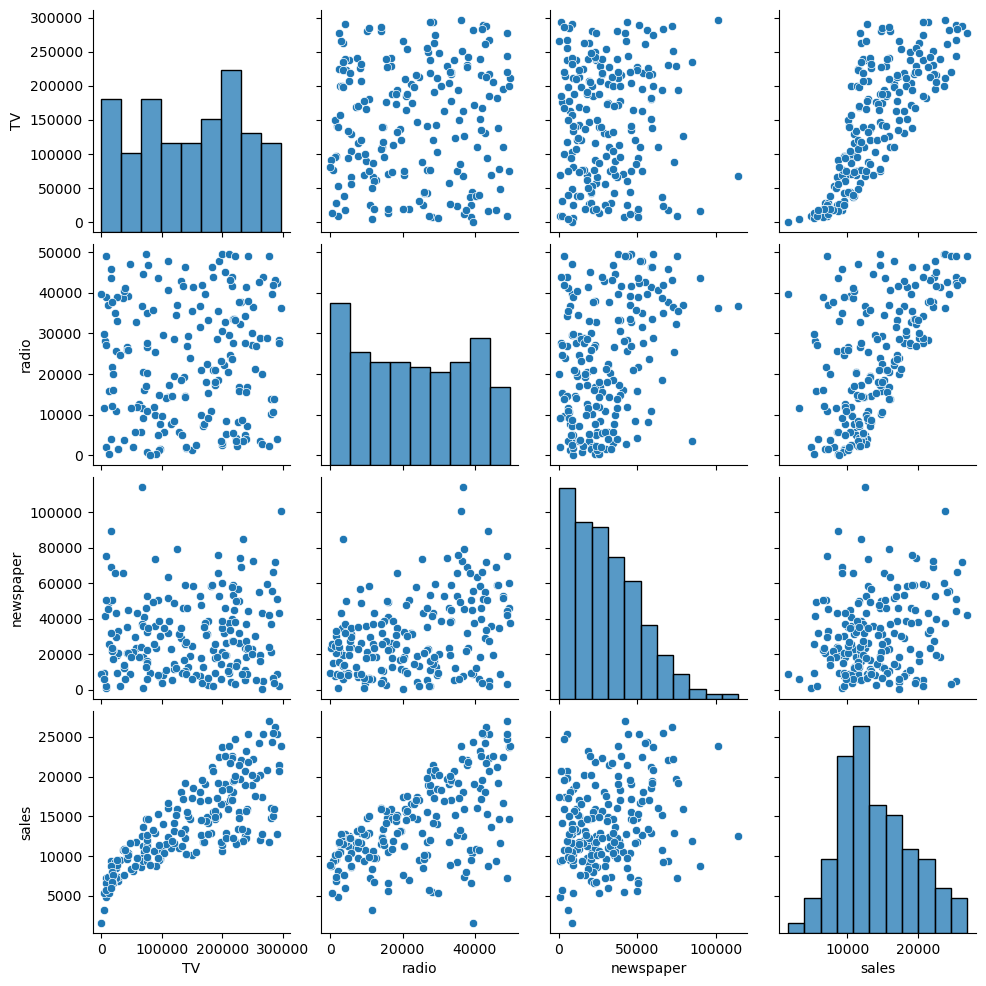

In [13]:
sns.pairplot(df)
plt.show()

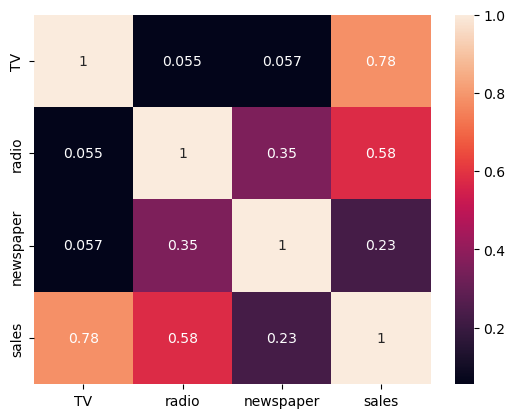

In [14]:
sns.heatmap(df.corr(), annot=True)
plt.show()

### **Data Cleaning**

In [15]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

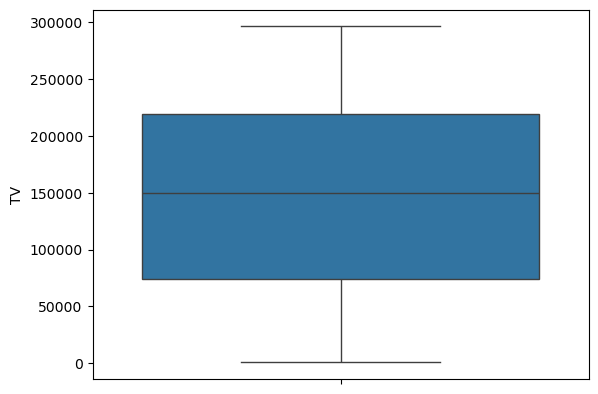

In [17]:
sns.boxplot(df["TV"])
plt.show()

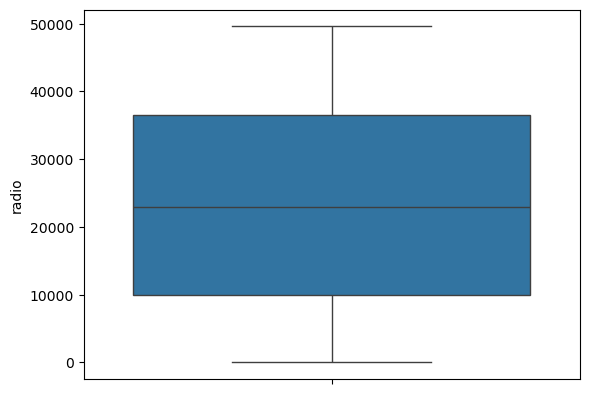

In [18]:
sns.boxplot(df["radio"])
plt.show()

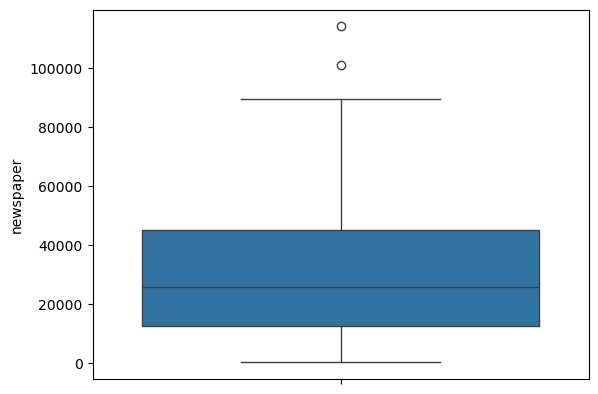

In [20]:
sns.boxplot(df["newspaper"])
plt.show()

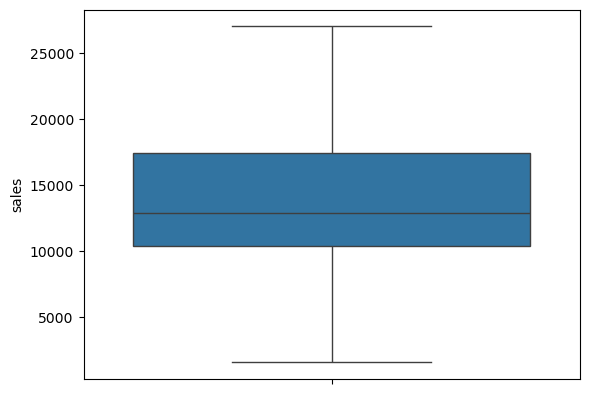

In [21]:
sns.boxplot(df["sales"])
plt.show()

In [22]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [24]:
!pip install feature_engine
from feature_engine.outliers import Winsorizer
win = Winsorizer(capping_method = 'iqr', tail = 'both', fold = 1.5, variables = ['newspaper'])
df = win.fit_transform(df[['newspaper']])
df

,newspaper
0,69200
1,45100
2,69300
3,58500
4,58400
...,...
195,13800
196,8100
197,6400
198,66200


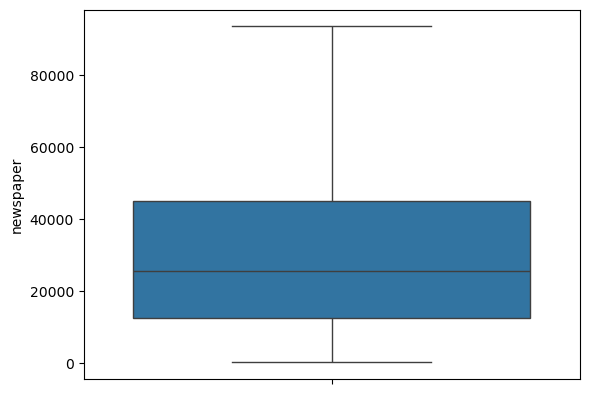

In [25]:
sns.boxplot(df["newspaper"])
plt.show()

### Train test split

In [30]:
# x = df[['TV','radio','newspaper']]
# y =df['sales']

In [31]:
x = df.drop(columns = 'sales')
y = df['sales']

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 45)

### Modeling

In [1]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()

In [47]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
model.intercept_

np.float64(3138.944470344528)

In [49]:
model.coef_

array([ 0.04701415,  0.18136082, -0.00851547])

### Prediction

In [50]:
train_predictions=model.predict(x_train)

In [51]:
test_predictions=model.predict(x_test)

### Evaluation

In [52]:
from sklearn.metrics import mean_absolute_error
print('MAE for test data:',mean_absolute_error(y_test,test_predictions))
print('MAE for train data:',mean_absolute_error(y_train,train_predictions))

MAE for test data: 1124.8397519900948
MAE for train data: 1341.1782546014574


In [53]:
from sklearn.metrics import mean_squared_error
print('MSE for test data:',mean_squared_error(y_test,test_predictions))
print('MSE for train data:',mean_squared_error(y_train,train_predictions))

MSE for test data: 2337050.5461647455
MSE for train data: 3058938.8996969615


In [54]:
print("RMSE for test data: ",np.sqrt(mean_squared_error(y_test,test_predictions)))
print("RMSE for train data: ",np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data:  1528.7414909541592
RMSE for train data:  1748.9822468215511


In [55]:
from sklearn.metrics import r2_score
print("R2 for test data: ",r2_score(y_test,test_predictions))
print("R2 for train data: ",r2_score(y_train,train_predictions))

R2 for test data:  0.9041908265578181
R2 for train data:  0.8896590670217261


In [56]:
model.score(x_test,y_test)

0.9041908265578181

In [57]:
model.score(x_train,y_train)

0.8896590670217261

### **Checklist**

For any Supervised Machine Learning Algorithm (Other than Linear Regression):

Check whether model has overfitting or underfitting problem

Is Test Accuracy ≈ Cross validation Score

Check model meets the business problem requirements

Finally, save the model and share to the deployment team

For Linear Regression, in addition we have to

### 2.Is Test Accuracy = Cross Validation Score

In [58]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

[0.87865198 0.91763212 0.92933032 0.81443904 0.89547829]
Cross Validation Score: 0.8871063495438435


### **Check for assumptions**
### 1.Linearity of Errors

In [59]:
test_res = y_test - test_predictions

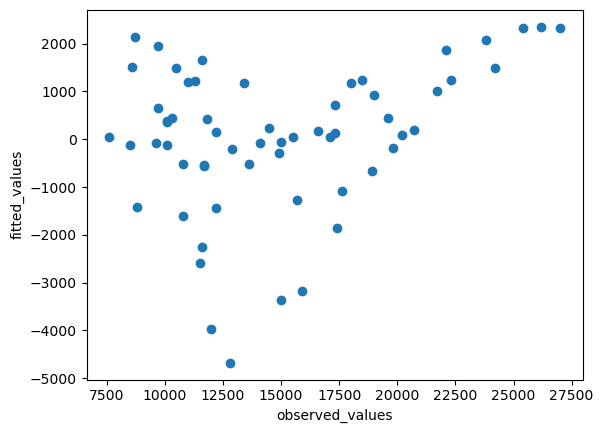

In [60]:
plt.scatter(y_test,test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

### **2.Normality of errors**

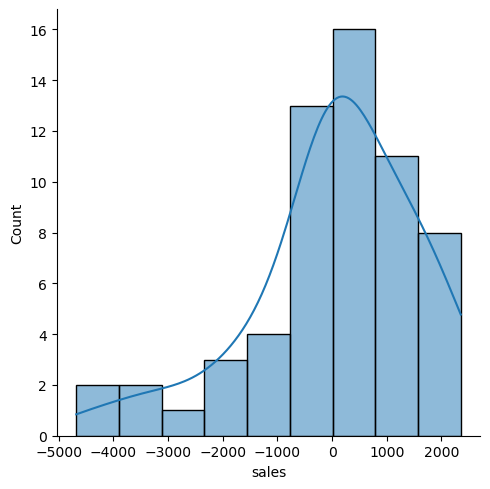

In [61]:
sns.displot(test_res,kde=True)
plt.show()

### **3.Equal Variance of Errors(Homoscadescity)**

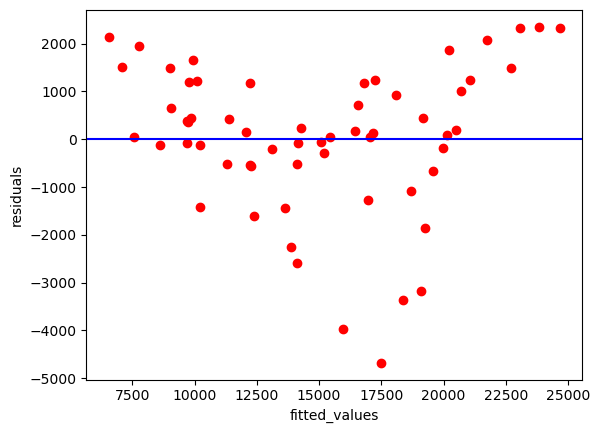

In [62]:
plt.scatter(test_predictions,test_res,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

### Make Predictions

In [63]:
import statsmodels.formula.api as smf
model2=smf.ols('y~x',data=df).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        10:58:23   Log-Likelihood:                -1767.7
No. Observations:                 200   AIC:                             3543.
Df Residuals:                     196   BIC:                             3557.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2938.8894    311.908      9.422      0.000    2323.762    3554.016
x[0]           0.0458      0.001     32.809      0.000       0.043       0.049
x[1]           0.1885      0.009     21.893      0.000       0.172       0.206
x[2]          -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                     4.54e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.54e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### **Step-6:Final Inferences**

In [65]:
model.predict([[38200,3700,13800]])

C:\Users\nagasri15\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5488.4065765])

### **Save a Model**

In [66]:
from joblib import dump

In [67]:
dump(model,'sales_model.joblib')

['sales_model.joblib']

### **Influence plot**

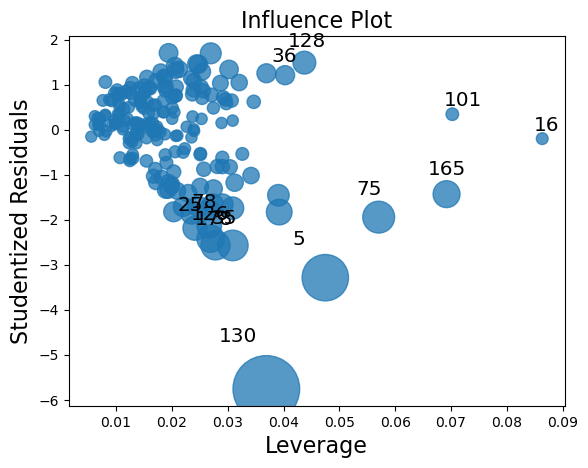

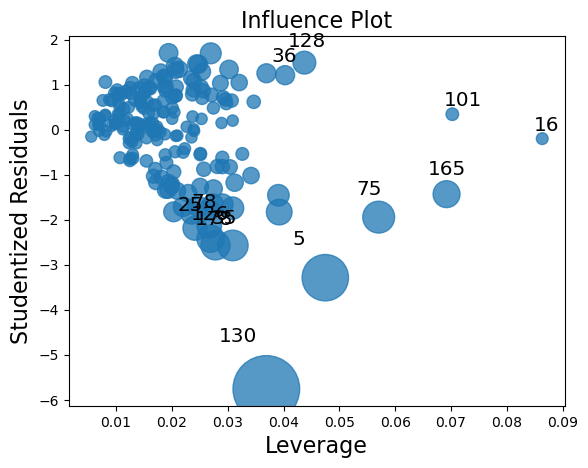

In [69]:
import statsmodels.api as sm
sm.graphics.influence_plot(model2)

In [70]:
df.loc[130]

TV             700
radio        39600
newspaper     8700
sales         1600
Name: 130, dtype: int64

In [72]:
df_new = df.drop(df.index[[130]],axis = 0)
df_new

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [78]:
model1=smf.ols(formula = 'sales ~ TV + radio + newspaper ',data=df_new).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     653.7
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.88e-101
Time:                        11:50:00   Log-Likelihood:                -1743.8
No. Observations:                 199   AIC:                             3496.
Df Residuals:                     195   BIC:                             3509.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3093.0655    290.332     10.654      0.000    2520.471    3665.660
TV             0.0448      0.001     34.425      0.000       0.042       0.047
radio          0.1939      0.008     24.130      0.000       0.178       0.210
newspaper     -0.0043      0.005     -0.777      0.438      -0.015       0.007
==============================================================================
Omnibus:                       21.217   Durbin-Watson:                   2.157
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.630
Skew:                          -0.835   Prob(JB):                     4.48e-06
Kurtosis:                       3.423   Cond. No.                     4.56e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.56e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

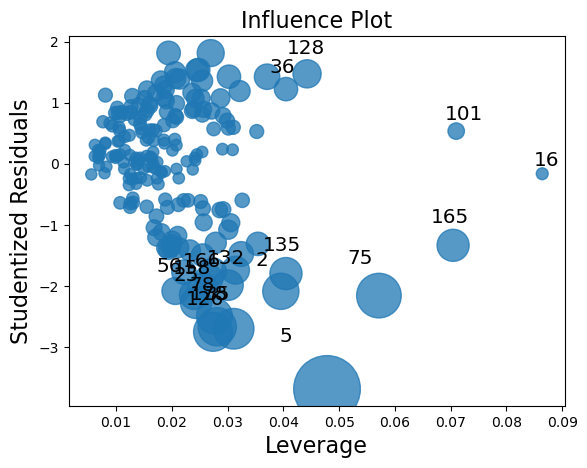

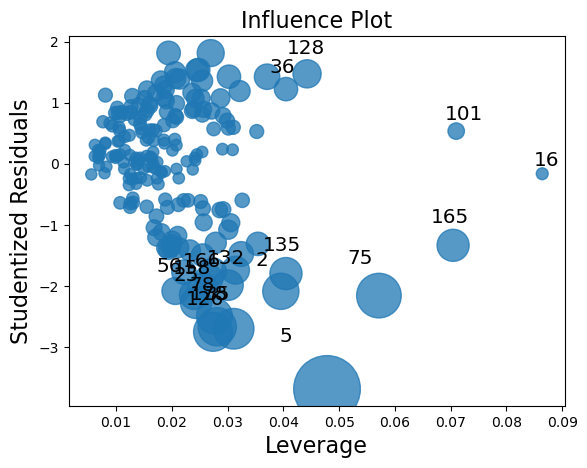

In [79]:
import statsmodels.api as sm
sm.graphics.influence_plot(model1)

### **Varaince Inflation Factor**
--> VIF measures the ratio between the variance for a given regression coefficient with only that variable in the 
    model versus the variance for a given regression coefficient with all variables in the model. 

In [80]:
rsq_TV = smf.ols('TV ~ radio + newspaper', data = df).fit()
rsq_TV.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     TV   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.4542
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.636
Time:                        12:00:13   Log-Likelihood:                -2554.9
No. Observations:                 200   AIC:                             5116.
Df Residuals:                     197   BIC:                             5126.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.366e+05   1.26e+04     10.826      0.000    1.12e+05    1.61e+05
radio          0.2298      0.440      0.523      0.602      -0.637       1.097
newspaper      0.1679      0.300      0.560      0.576      -0.423       0.759
==============================================================================
Omnibus:                       93.855   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.314
Skew:                          -0.089   Prob(JB):                      0.00212
Kurtosis:                       1.798   Cond. No.                     9.19e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.19e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [83]:
rsq_TV = smf.ols('TV ~ radio + newspaper', data = df).fit().rsquared
vif_TV = 1/(1-rsq_TV)

rsq_radio = smf.ols('TV ~ radio + newspaper', data = df).fit().rsquared
vif_radio = 1/(1-rsq_radio)

rsq_newspaper = smf.ols('TV ~ radio + newspaper', data = df).fit().rsquared
vif_newspaper = 1/(1-rsq_newspaper)


In [85]:
d1 = { 'Variables': ['TV', 'radio', 'newspaper'],'VIF':[vif_TV, vif_radio, vif_newspaper]}
vif_frame = pd.DataFrame(d1)
vif_frame

,Variables,VIF
0,TV,1.004611
1,radio,1.004611
2,newspaper,1.004611


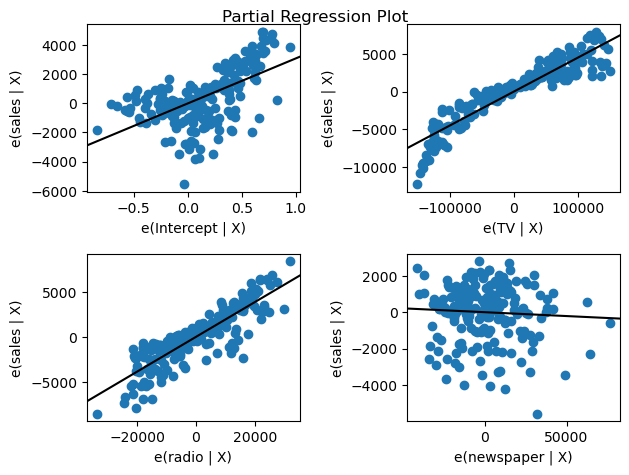

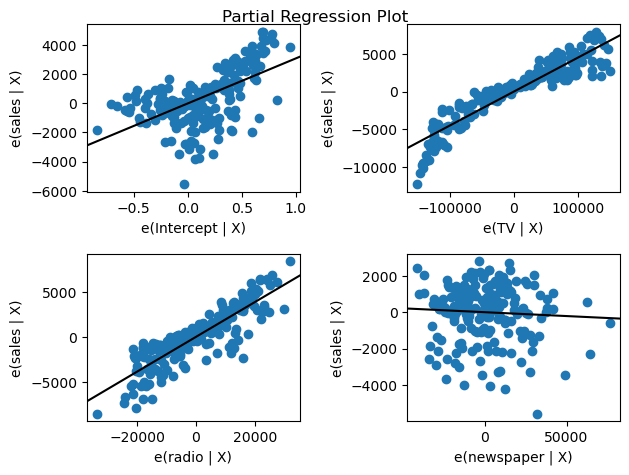

In [87]:
sm.graphics.plot_partregress_grid(model1)

### **Final model including TV and Radio only**

In [88]:
final_model = smf.ols(formula = 'sales ~ TV + radio', data = df).fit()
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           4.83e-98
Time:                        12:26:56   Log-Likelihood:                -1767.7
No. Observations:                 200   AIC:                             3541.
Df Residuals:                     197   BIC:                             3551.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2921.0999    294.490      9.919      0.000    2340.343    3501.857
TV             0.0458      0.001     32.909      0.000       0.043       0.048
radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                     4.25e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.25e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""